<a href="https://colab.research.google.com/github/mmantey-ops/Group-5-Quantum-Password-Hacking/blob/main/docs/start/start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hello Qubit

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/start/start"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

# Grover's Algorithm: 2-Bit Implementation

In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")

print("Libraries Successfully Imported")

Libraries Successfully Imported


In [ ]:
#SCAFFOLDING

import cirq
from typing import List


def create_circuit() -> cirq.Circuit:
    """
    Create and assemble the Grover circuit.
    """

    # Create the qubits
    qubits = [
        # TODO: Define the qubits
    ]

    # Create the circuit
    circuit = cirq.Circuit()

    # TODO: Initialize the qubits in superposition

    # TODO: Apply the oracle

    # TODO: Apply the diffusion operator

    # TODO: Measure the qubits

    return circuit


def initialize_superposition(circuit: cirq.Circuit,
                             qubits: List[cirq.Qid]) -> None:
    """
    Place all qubits into an equal superposition.
    """

    # TODO: Apply Hadamard gates


def oracle(circuit: cirq.Circuit,
           qubits: List[cirq.Qid],
           target_state: str) -> None:
    """
    Mark the target state with a phase flip.
    """

    # TODO: Implement the oracle


def diffusion(circuit: cirq.Circuit,
              qubits: List[cirq.Qid]) -> None:
    """
    Amplify the probability of the marked state.
    """

    # TODO: Apply the diffusion operator


def measure(circuit: cirq.Circuit,
            qubits: List[cirq.Qid]) -> None:
    """
    Measure every qubit.
    """

    # TODO: Measure the qubits


def run(circuit: cirq.Circuit,
        repetitions: int = 1000):
    """
    Execute the circuit on the simulator.
    """

    simulator = cirq.Simulator()

    # TODO: Run the simulation

    return


def analyze(results) -> None:
    """
    Display the measurement results.
    """

    # TODO: Print the histogram


def main():

    # Define the target state
    target_state = "11"

    # Build the circuit
    circuit = create_circuit()

    # Run the simulation
    results = run(circuit)

    # Analyze the results
    analyze(results)


if __name__ == "__main__":
    main()


Iterations: 1
Success Probability: 1.0
Measurement Histogram:
Counter({3: 1000})

Iterations: 2
Success Probability: 0.27
Measurement Histogram:
Counter({3: 270, 2: 245, 0: 245, 1: 240})

Iterations: 3
Success Probability: 0.233
Measurement Histogram:
Counter({0: 278, 2: 249, 1: 240, 3: 233})

Iterations: 4
Success Probability: 1.0
Measurement Histogram:
Counter({3: 1000})

Iterations: 5
Success Probability: 0.232
Measurement Histogram:
Counter({0: 267, 1: 255, 2: 246, 3: 232})

Final Circuit
(0, 0): ───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───M('result')───
               │           │           │           │           │           │           │           │           │           │           │
(0, 1): ───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───@───H───X───@───X───H───M─────────────


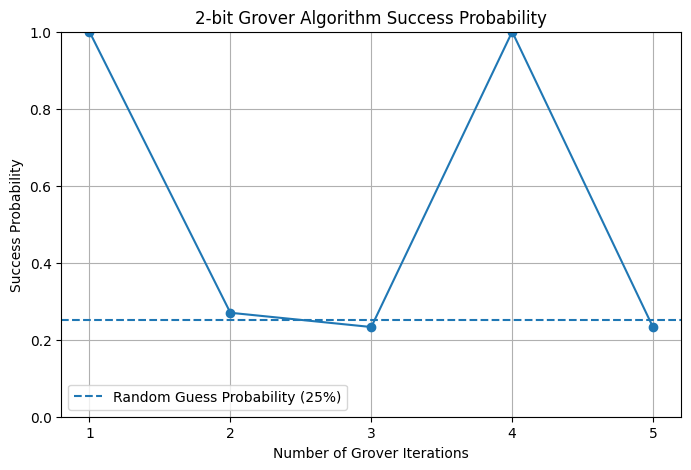

In [2]:
# Define the qubits

q0 = cirq.GridQubit(0, 0)
q1 = cirq.GridQubit(0, 1)

qubits = [q0, q1]


# Oracle
# Marks the target state |11>

def oracle(circuit):

    # CZ flips the phase of |11>
    circuit.append(
        cirq.CZ(q0, q1)
    )


# Diffusion Operator
# Amplifies the marked state

def diffusion(circuit):

    circuit.append([
        cirq.H(q0),
        cirq.H(q1),

        cirq.X(q0),
        cirq.X(q1),

        cirq.CZ(q0, q1),

        cirq.X(q0),
        cirq.X(q1),

        cirq.H(q0),
        cirq.H(q1)
    ])


# Create Grover Circuit

def create_grover_circuit(iterations):

    circuit = cirq.Circuit()


    # Create superposition
    circuit.append([
        cirq.H(q0),
        cirq.H(q1)
    ])


    # Apply Grover iterations
    for i in range(iterations):

        oracle(circuit)

        diffusion(circuit)


    # Measurement
    circuit.append(
        cirq.measure(
            q0,
            q1,
            key="result"
        )
    )


    return circuit



# Run Simulation

def run_experiment(iterations, repetitions):

    simulator = cirq.Simulator()


    circuit = create_grover_circuit(iterations)


    results = simulator.run(
        circuit,
        repetitions=repetitions
    )


    histogram = results.histogram(
        key="result"
    )


    # Target state |11> = decimal 3
    target = 3


    success_probability = (
        histogram.get(target,0)
        /
        repetitions
    )


    return success_probability, histogram, circuit


# Run Multiple Trials

max_iterations = 5
repetitions = 1000


probabilities = []


for iterations in range(1,max_iterations+1):

    probability, histogram, circuit = run_experiment(
        iterations,
        repetitions
    )


    probabilities.append(probability)


    print("\n===================================")
    print("Iterations:", iterations)

    print(
        "Success Probability:",
        round(probability,4)
    )

    print(
        "Measurement Histogram:"
    )

    print(histogram)



# Print Final Circuit

print("\nFinal Circuit")
print(circuit)


# Plot Success Probability

plt.figure(figsize=(8,5))


plt.plot(
    range(1,max_iterations+1),
    probabilities,
    marker="o"
)


plt.axhline(
    y=0.25,
    linestyle="--",
    label="Random Guess Probability (25%)"
)


plt.xlabel(
    "Number of Grover Iterations"
)


plt.ylabel(
    "Success Probability"
)


plt.title(
    "2-bit Grover Algorithm Success Probability"
)


plt.xticks(
    range(1,max_iterations+1)
)


plt.ylim(
    0,
    1
)


plt.grid(True)

plt.legend()

plt.show()

# Grover's Algorithm: 3-Bit Implementation


Iterations: 1
Success Probability: 0.8010
Measurement Histogram:
Counter({5: 801, 4: 32, 7: 31, 6: 31, 0: 30, 2: 29, 1: 24, 3: 22})

Iterations: 2
Success Probability: 0.9400
Measurement Histogram:
Counter({5: 940, 6: 13, 7: 11, 2: 10, 3: 8, 1: 7, 0: 6, 4: 5})

Iterations: 3
Success Probability: 0.3190
Measurement Histogram:
Counter({5: 319, 4: 113, 7: 107, 6: 102, 0: 94, 3: 93, 1: 89, 2: 83})

Iterations: 4
Success Probability: 0.0180
Measurement Histogram:
Counter({1: 153, 7: 145, 4: 143, 6: 141, 2: 135, 0: 134, 3: 131, 5: 18})

Iterations: 5
Success Probability: 0.5480
Measurement Histogram:
Counter({5: 548, 6: 71, 4: 71, 3: 70, 7: 69, 2: 61, 0: 60, 1: 50})

Final Circuit
(0, 0): ───H───────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────M('result')───
                   │                   │                   │                   │     

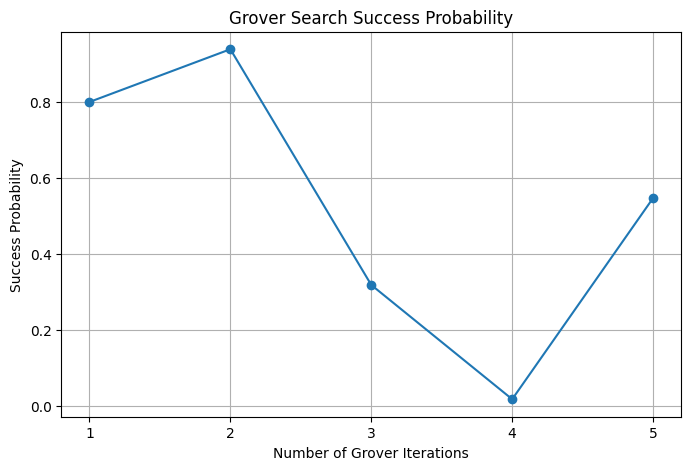

In [3]:
# 3-BIT VERSION

PASSWORD = "101"

# Create three qubits

q0 = cirq.GridQubit(0, 0)
q1 = cirq.GridQubit(0, 1)
q2 = cirq.GridQubit(0, 2)

qubits = [q0, q1, q2]

# Oracle
# Marks the correct password with a phase flip

def oracle(circuit, qubits, password):

    # Flip qubits that correspond to 0 bits
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))

    # Multi-controlled Z
    circuit.append(cirq.H(qubits[2]))
    circuit.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    circuit.append(cirq.H(qubits[2]))

    # Undo temporary X gates
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))

# Diffusion Operator

def diffusion(circuit, qubits):

    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))

    circuit.append(cirq.H(qubits[2]))
    circuit.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    circuit.append(cirq.H(qubits[2]))

    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))

# Build Grover Circuit

def build_circuit(password, iterations):

    circuit = cirq.Circuit()

    # Equal superposition
    circuit.append(cirq.H.on_each(*qubits))

    # Grover iterations
    for _ in range(iterations):
        oracle(circuit, qubits, password)
        diffusion(circuit, qubits)

    # Measure
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Run one experiment

def run_experiment(password, iterations, repetitions):

    simulator = cirq.Simulator()

    circuit = build_circuit(password, iterations)

    results = simulator.run(circuit, repetitions=repetitions)

    histogram = results.histogram(key="result")

    target = int(password, 2)

    success = histogram.get(target, 0)

    probability = success / repetitions

    return probability, histogram, circuit

# Multiple Trials

repetitions = 1000
max_iterations = 5

success_rates = []

for iterations in range(1, max_iterations + 1):

    probability, histogram, circuit = run_experiment(
        PASSWORD,
        iterations,
        repetitions
    )

    success_rates.append(probability)

    print("\n===================================")
    print(f"Iterations: {iterations}")
    print(f"Success Probability: {probability:.4f}")
    print("Measurement Histogram:")
    print(histogram)

# Display the final circuit

print("\nFinal Circuit")
print(circuit)

# Plot Success Probability

plt.figure(figsize=(8,5))
plt.plot(
    range(1, max_iterations + 1),
    success_rates,
    marker="o"
)

plt.title("Grover Search Success Probability")
plt.xlabel("Number of Grover Iterations")
plt.ylabel("Success Probability")
plt.xticks(range(1, max_iterations + 1))
plt.grid(True)

plt.show()

# Grover's Algorithm: 4-Bit Implementation

-----------------------------
Iterations: 1
Ideal Success: 0.057
Noisy Success: 0.077
-----------------------------
Iterations: 2
Ideal Success: 0.061
Noisy Success: 0.087
-----------------------------
Iterations: 3
Ideal Success: 0.065
Noisy Success: 0.05
-----------------------------
Iterations: 4
Ideal Success: 0.059
Noisy Success: 0.053
-----------------------------
Iterations: 5
Ideal Success: 0.066
Noisy Success: 0.072
-----------------------------
Iterations: 6
Ideal Success: 0.059
Noisy Success: 0.068
-----------------------------
Iterations: 7
Ideal Success: 0.066
Noisy Success: 0.079
-----------------------------
Iterations: 8
Ideal Success: 0.059
Noisy Success: 0.067
-----------------------------
Iterations: 9
Ideal Success: 0.072
Noisy Success: 0.069
-----------------------------
Iterations: 10
Ideal Success: 0.057
Noisy Success: 0.063

Classical Average Attempts:
8.0

Grover Optimal Iterations:
3.14159


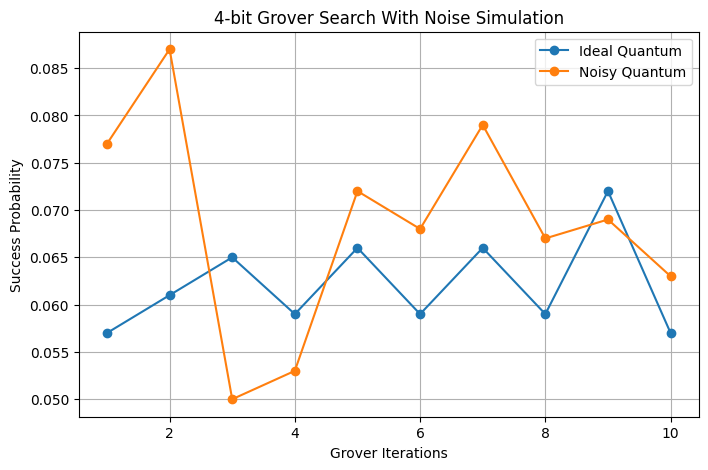

In [4]:
# Password
# Hidden from the search algorithm

PASSWORD = "1011"

# Create 4 qubits

qubits = [
    cirq.GridQubit(0,0),
    cirq.GridQubit(0,1),
    cirq.GridQubit(0,2),
    cirq.GridQubit(0,3)
]

# Oracle

def oracle(circuit, qubits, password):

    # Convert zeros into ones
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))

    # 4-qubit controlled phase flip
    circuit.append(cirq.H(qubits[3]))
    circuit.append(
        cirq.CCX(qubits[0], qubits[1], qubits[2])
    )
    circuit.append(cirq.CNOT(qubits[2], qubits[3]))
    circuit.append(cirq.H(qubits[3]))

    # Undo zero conversions
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))


# Diffusion Operator

def diffusion(circuit, qubits):

    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))

    circuit.append(cirq.H(qubits[3]))

    circuit.append(
        cirq.CCX(qubits[0], qubits[1], qubits[2])
    )

    circuit.append(cirq.H(qubits[3]))

    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))


# Build Grover Circuit

def grover_circuit(password, iterations):

    circuit = cirq.Circuit()

    # Superposition
    circuit.append(cirq.H.on_each(*qubits))


    for i in range(iterations):
        oracle(circuit, qubits, password)
        diffusion(circuit, qubits)


    circuit.append(
        cirq.measure(*qubits, key="result")
    )

    return circuit


# Run Ideal Simulation

def run_grover(password, iterations, repetitions):

    simulator = cirq.Simulator()

    circuit = grover_circuit(
        password,
        iterations
    )

    results = simulator.run(
        circuit,
        repetitions=repetitions
    )


    histogram = results.histogram(
        key="result"
    )


    target = int(password,2)

    probability = (
        histogram.get(target,0)
        /
        repetitions
    )

    return probability


# Noise Simulation

def run_noisy(password, iterations, repetitions):

    noise = cirq.depolarize(p=0.01)

    circuit = grover_circuit(
        password,
        iterations
    )


    noisy_circuit = cirq.Circuit()

    for moment in circuit:
        noisy_circuit.append(moment)
        noisy_circuit.append(
            noise.on_each(*qubits)
        )


    simulator = cirq.DensityMatrixSimulator()


    results = simulator.run(
        noisy_circuit,
        repetitions=repetitions
    )


    histogram = results.histogram(
        key="result"
    )


    target = int(password,2)


    return (
        histogram.get(target,0)
        /
        repetitions
    )


# Run Experiments

max_iterations = 10

ideal_results = []
noise_results = []


for i in range(1,max_iterations+1):

    ideal = run_grover(
        PASSWORD,
        i,
        1000
    )


    noisy = run_noisy(
        PASSWORD,
        i,
        1000
    )


    ideal_results.append(ideal)
    noise_results.append(noisy)


    print("-----------------------------")
    print("Iterations:",i)
    print("Ideal Success:",ideal)
    print("Noisy Success:",noisy)


# Classical Brute Force Comparison


space_size = 2**len(PASSWORD)

classical_average = space_size/2


grover_iterations = (
    3.14159/4
    *
    space_size**0.5
)


print("\nClassical Average Attempts:")
print(classical_average)


print("\nGrover Optimal Iterations:")
print(grover_iterations)


# Plot Results

plt.figure(figsize=(8,5))

plt.plot(
    range(1,max_iterations+1),
    ideal_results,
    marker="o",
    label="Ideal Quantum"
)


plt.plot(
    range(1,max_iterations+1),
    noise_results,
    marker="o",
    label="Noisy Quantum"
)


plt.xlabel(
    "Grover Iterations"
)

plt.ylabel(
    "Success Probability"
)

plt.title(
    "4-bit Grover Search With Noise Simulation"
)

plt.legend()

plt.grid()

plt.show()